### Import the required libraries

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Loading the DataSet

In [11]:
df = pd.read_csv("data.csv",encoding="ISO-8859-1")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


### Number of Rows and Columns

In [13]:
df.shape

(541909, 8)

### Access Last Five Rows

In [14]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/2011 12:50,4.95,12680.0,France


### Display total columns from the Dataset

In [15]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

### Getting all columns one by one

In [16]:
for col in df.columns:
    print(col)

InvoiceNo
StockCode
Description
Quantity
InvoiceDate
UnitPrice
CustomerID
Country


### Renaming Column names
##### InvoiceNo = invoice_num
##### StockCode = stock_code
##### Description = description
##### Quantity = quantity
##### InvoiceDate = invoice_date
##### UnitPrice = unit_price
##### CustomerID = cust_id
##### Country = country

In [17]:
rename_dict = {
    'InvoiceNo' : 'invoice_num',  
    'StockCode' :'stock_code',
    'Description' :'description',
    'Quantity' :'quantity',
    'InvoiceDate' : 'invoice_date',
    'UnitPrice' : 'unit_price',
    'CustomerID' : 'cust_id',
    'Country' : 'country'
}
df.rename(columns = rename_dict,inplace=True)

### After changing names check new column names

In [18]:
df.columns

Index(['invoice_num', 'stock_code', 'description', 'quantity', 'invoice_date',
       'unit_price', 'cust_id', 'country'],
      dtype='str')

### Check the initial data

In [19]:
df.head()

,invoice_num,stock_code,description,quantity,invoice_date,unit_price,cust_id,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


### Data Cleaning

### Check column types

In [20]:
df.dtypes

invoice_num         str
stock_code          str
description         str
quantity          int64
invoice_date        str
unit_price      float64
cust_id         float64
country             str
dtype: object

### DataFrame information

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   invoice_num   541909 non-null  str    
 1   stock_code    541909 non-null  str    
 2   description   540455 non-null  str    
 3   quantity      541909 non-null  int64  
 4   invoice_date  541909 non-null  str    
 5   unit_price    541909 non-null  float64
 6   cust_id       406829 non-null  float64
 7   country       541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


### Check missing values for each columns

In [22]:
df.isnull()

,invoice_num,stock_code,description,quantity,invoice_date,unit_price,cust_id,country
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
541904,False,False,False,False,False,False,False,False
541905,False,False,False,False,False,False,False,False
541906,False,False,False,False,False,False,False,False
541907,False,False,False,False,False,False,False,False


### Number of columns

In [23]:
len(df.columns)
df.shape

(541909, 8)

### Check the missing values count on each column

In [24]:
df.isnull().sum()

invoice_num          0
stock_code           0
description       1454
quantity             0
invoice_date         0
unit_price           0
cust_id         135080
country              0
dtype: int64

### Check missing values count on each column, applying sort

In [25]:
df.isnull().sum().sort_values(ascending=False)

cust_id         135080
description       1454
stock_code           0
invoice_num          0
quantity             0
invoice_date         0
unit_price           0
country              0
dtype: int64

### Convert invoice_date data type into datetime data type

In [26]:
# m/d/Y h:m
df['invoice_date'] = pd.to_datetime(df.invoice_date, format='%m/%d/%Y %H:%M')

In [27]:
df.dtypes

invoice_num                str
stock_code                 str
description                str
quantity                 int64
invoice_date    datetime64[us]
unit_price             float64
cust_id                float64
country                    str
dtype: object

In [28]:
df.head()

,invoice_num,stock_code,description,quantity,invoice_date,unit_price,cust_id,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


### Check the data type of customer_id

In [29]:
df.dtypes

invoice_num                str
stock_code                 str
description                str
quantity                 int64
invoice_date    datetime64[us]
unit_price             float64
cust_id                float64
country                    str
dtype: object

#### Drop the missing values

In [30]:
df_new = df.dropna()

In [31]:
df_new.isnull().sum().sort_values(ascending=False)

invoice_num     0
stock_code      0
description     0
quantity        0
invoice_date    0
unit_price      0
cust_id         0
country         0
dtype: int64

In [32]:
df_new.dtypes

invoice_num                str
stock_code                 str
description                str
quantity                 int64
invoice_date    datetime64[us]
unit_price             float64
cust_id                float64
country                    str
dtype: object

### Convert cust_id float type into integer type

In [33]:
df_new['cust_id'] = df_new['cust_id'].astype('int64')

In [34]:
df_new.dtypes

invoice_num                str
stock_code                 str
description                str
quantity                 int64
invoice_date    datetime64[us]
unit_price             float64
cust_id                  int64
country                    str
dtype: object

In [35]:
len(df_new.quantity < 0)

406829

### Remove negative values from quantity column

In [36]:
cond = df_new.quantity > 0
df_new = df_new[cond]   # df_new[df_new.quantity > 0]
df_new.describe().round(2)


,quantity,invoice_date,unit_price,cust_id
count,397924.00,397924,397924.00,397924.00
mean,13.02,2011-07-10 23:43:36.912476,3.12,15294.32
min,1.00,2010-12-01 08:26:00,0.00,12346.00
25%,2.00,2011-04-07 11:12:00,1.25,13969.00
50%,6.00,2011-07-31 14:39:00,1.95,15159.00
75%,12.00,2011-10-20 14:33:00,3.75,16795.00
max,80995.00,2011-12-09 12:50:00,8142.75,18287.00
std,180.42,NaN,22.10,1713.17


In [37]:
df.dtypes
df_new['cust_id'] = df_new['cust_id'].astype('int64')

In [38]:
df_new.head()

,invoice_num,stock_code,description,quantity,invoice_date,unit_price,cust_id,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


### Adding a new column - amount_spent

In [39]:
df_new['amount_spent'] = df_new['quantity'] * df_new['unit_price']

In [40]:
df_new.head()

,invoice_num,stock_code,description,quantity,invoice_date,unit_price,cust_id,country,amount_spent
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


### Rearranging columns for more readability

In [41]:
# invoice_num, invoice_date, stock_code, decription, quantity, unit_price, amount_spent, cust_id, country
col_order = ['invoice_num', 'invoice_date', 'stock_code', 'description', 'quantity', 'unit_price', 'amount_spent', 'cust_id', 'country']
df_new = df_new[col_order]
df_new.head()

,invoice_num,invoice_date,stock_code,description,quantity,unit_price,amount_spent,cust_id,country
0,536365,2010-12-01 08:26:00,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,15.30,17850,United Kingdom
1,536365,2010-12-01 08:26:00,71053,WHITE METAL LANTERN,6,3.39,20.34,17850,United Kingdom
2,536365,2010-12-01 08:26:00,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,22.00,17850,United Kingdom
3,536365,2010-12-01 08:26:00,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,20.34,17850,United Kingdom
4,536365,2010-12-01 08:26:00,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,20.34,17850,United Kingdom


In [42]:
df_new['invoice_date']

0        2010-12-01 08:26:00
1        2010-12-01 08:26:00
2        2010-12-01 08:26:00
3        2010-12-01 08:26:00
4        2010-12-01 08:26:00
                 ...        
541904   2011-12-09 12:50:00
541905   2011-12-09 12:50:00
541906   2011-12-09 12:50:00
541907   2011-12-09 12:50:00
541908   2011-12-09 12:50:00
Name: invoice_date, Length: 397924, dtype: datetime64[us]

In [43]:
df_new.invoice_date

0        2010-12-01 08:26:00
1        2010-12-01 08:26:00
2        2010-12-01 08:26:00
3        2010-12-01 08:26:00
4        2010-12-01 08:26:00
                 ...        
541904   2011-12-09 12:50:00
541905   2011-12-09 12:50:00
541906   2011-12-09 12:50:00
541907   2011-12-09 12:50:00
541908   2011-12-09 12:50:00
Name: invoice_date, Length: 397924, dtype: datetime64[us]

### Accessing year value from invoice_date

In [44]:
df_new['invoice_date'].dt.month

0         12
1         12
2         12
3         12
4         12
          ..
541904    12
541905    12
541906    12
541907    12
541908    12
Name: invoice_date, Length: 397924, dtype: int32

In [45]:
n = [1, 2, 3, 4, 5]
d = list(map(lambda x: x * 2, n))
print(d)

[2, 4, 6, 8, 10]


In [46]:
y = 2010
m = 12
y_m = 100 * 2010 + 12
y_m

201012

In [47]:
df_new.head(2)

,invoice_num,invoice_date,stock_code,description,quantity,unit_price,amount_spent,cust_id,country
0,536365,2010-12-01 08:26:00,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,15.30,17850,United Kingdom
1,536365,2010-12-01 08:26:00,71053,WHITE METAL LANTERN,6,3.39,20.34,17850,United Kingdom


### Lets insert year_month column in the 2nd position

In [48]:
c1 = 'year_month'
v1 = df_new['invoice_date'].map(lambda col : 100 * (col.year) + col.month)
df_new.insert(loc = 2, column = c1, value = v1)
df_new

,invoice_num,invoice_date,year_month,stock_code,description,quantity,unit_price,amount_spent,cust_id,country
0,536365,2010-12-01 08:26:00,201012,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,15.30,17850,United Kingdom
1,536365,2010-12-01 08:26:00,201012,71053,WHITE METAL LANTERN,6,3.39,20.34,17850,United Kingdom
2,536365,2010-12-01 08:26:00,201012,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,22.00,17850,United Kingdom
3,536365,2010-12-01 08:26:00,201012,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,20.34,17850,United Kingdom
4,536365,2010-12-01 08:26:00,201012,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,20.34,17850,United Kingdom
...,...,...,...,...,...,...,...,...,...,...
541904,581587,2011-12-09 12:50:00,201112,22613,PACK OF 20 SPACEBOY NAPKINS,12,0.85,10.20,12680,France
541905,581587,2011-12-09 12:50:00,201112,22899,CHILDREN'S APRON DOLLY GIRL,6,2.10,12.60,12680,France
541906,581587,2011-12-09 12:50:00,201112,23254,CHILDRENS CUTLERY DOLLY GIRL,4,4.15,16.60,12680,France
541907,581587,2011-12-09 12:50:00,201112,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,4.15,16.60,12680,France


#### Adding month column to the existing DataFrame

In [49]:
c2 = 'month'
v2 = df_new.invoice_date.dt.month
df_new.insert(loc = 3, column = c2, value = v2)
df_new.head(2)

,invoice_num,invoice_date,year_month,month,stock_code,description,quantity,unit_price,amount_spent,cust_id,country
0,536365,2010-12-01 08:26:00,201012,12,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,15.30,17850,United Kingdom
1,536365,2010-12-01 08:26:00,201012,12,71053,WHITE METAL LANTERN,6,3.39,20.34,17850,United Kingdom


In [50]:
df_new.head(2)

,invoice_num,invoice_date,year_month,month,stock_code,description,quantity,unit_price,amount_spent,cust_id,country
0,536365,2010-12-01 08:26:00,201012,12,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,15.30,17850,United Kingdom
1,536365,2010-12-01 08:26:00,201012,12,71053,WHITE METAL LANTERN,6,3.39,20.34,17850,United Kingdom


In [51]:
df_new.invoice_date.dt.dayofweek
# Monday = 0, Tuesday = 1, Wednesday = 2, .... Sunday = 6
df_new.invoice_date.dt.dayofweek + 1
# Monday = 1 Tuesday = 2, Wednesday = 3, .... Sunday = 7

0         3
1         3
2         3
3         3
4         3
         ..
541904    5
541905    5
541906    5
541907    5
541908    5
Name: invoice_date, Length: 397924, dtype: int32

In [52]:
c3 = 'day'
v3 = (df_new.invoice_date.dt.dayofweek) + 1
df_new.insert(loc = 4, column = c3, value = v3)
df_new.head()

,invoice_num,invoice_date,year_month,month,day,stock_code,description,quantity,unit_price,amount_spent,cust_id,country
0,536365,2010-12-01 08:26:00,201012,12,3,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,15.30,17850,United Kingdom
1,536365,2010-12-01 08:26:00,201012,12,3,71053,WHITE METAL LANTERN,6,3.39,20.34,17850,United Kingdom
2,536365,2010-12-01 08:26:00,201012,12,3,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,22.00,17850,United Kingdom
3,536365,2010-12-01 08:26:00,201012,12,3,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,20.34,17850,United Kingdom
4,536365,2010-12-01 08:26:00,201012,12,3,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,20.34,17850,United Kingdom


#### Add hour column to existing DataFrame

In [53]:
c4 = 'hour'
v4 = df_new.invoice_date.dt.hour
df_new.insert(loc = 5,column =c4,value =v4)
df_new.head()

,invoice_num,invoice_date,year_month,month,day,hour,stock_code,description,quantity,unit_price,amount_spent,cust_id,country
0,536365,2010-12-01 08:26:00,201012,12,3,8,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,15.30,17850,United Kingdom
1,536365,2010-12-01 08:26:00,201012,12,3,8,71053,WHITE METAL LANTERN,6,3.39,20.34,17850,United Kingdom
2,536365,2010-12-01 08:26:00,201012,12,3,8,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,22.00,17850,United Kingdom
3,536365,2010-12-01 08:26:00,201012,12,3,8,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,20.34,17850,United Kingdom
4,536365,2010-12-01 08:26:00,201012,12,3,8,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,20.34,17850,United Kingdom


In [54]:
df_new.columns

Index(['invoice_num', 'invoice_date', 'year_month', 'month', 'day', 'hour',
       'stock_code', 'description', 'quantity', 'unit_price', 'amount_spent',
       'cust_id', 'country'],
      dtype='str')

### Exploratory Data Analysis(EDA)

In [55]:
df_new.groupby(by = ['cust_id']).count()

,invoice_num,invoice_date,year_month,month,day,hour,stock_code,description,quantity,unit_price,amount_spent,country
cust_id,,,,,,,,,,,,
12346,1,1,1,1,1,1,1,1,1,1,1,1
12347,182,182,182,182,182,182,182,182,182,182,182,182
12348,31,31,31,31,31,31,31,31,31,31,31,31
12349,73,73,73,73,73,73,73,73,73,73,73,73
12350,17,17,17,17,17,17,17,17,17,17,17,17
...,...,...,...,...,...,...,...,...,...,...,...,...
18280,10,10,10,10,10,10,10,10,10,10,10,10
18281,7,7,7,7,7,7,7,7,7,7,7,7
18282,12,12,12,12,12,12,12,12,12,12,12,12


In [56]:
df_new.groupby(by = ['cust_id','country']).count()

,,invoice_num,invoice_date,year_month,month,day,hour,stock_code,description,quantity,unit_price,amount_spent
cust_id,country,,,,,,,,,,,
12346,United Kingdom,1,1,1,1,1,1,1,1,1,1,1
12347,Iceland,182,182,182,182,182,182,182,182,182,182,182
12348,Finland,31,31,31,31,31,31,31,31,31,31,31
12349,Italy,73,73,73,73,73,73,73,73,73,73,73
12350,Norway,17,17,17,17,17,17,17,17,17,17,17
...,...,...,...,...,...,...,...,...,...,...,...,...
18280,United Kingdom,10,10,10,10,10,10,10,10,10,10,10
18281,United Kingdom,7,7,7,7,7,7,7,7,7,7,7
18282,United Kingdom,12,12,12,12,12,12,12,12,12,12,12


In [57]:
orders = df_new.groupby(by = ['cust_id','country'],as_index = False)['invoice_num'].count()

In [58]:
print(orders.head(2))

   cust_id         country  invoice_num
0    12346  United Kingdom            1
1    12347         Iceland          182


## Check TOP 5 most number of orders

In [59]:
orders.sort_values(by = 'invoice_num', ascending=False).head()

,cust_id,country,invoice_num
4019,17841,United Kingdom,7847
1888,14911,EIRE,5677
1298,14096,United Kingdom,5111
334,12748,United Kingdom,4596
1670,14606,United Kingdom,2700


### How much money spent by each customers?

In [60]:
money_spent = df_new.groupby(by =  ['cust_id','country'],as_index = False)['amount_spent'].sum()
print(money_spent)

      cust_id         country  amount_spent
0       12346  United Kingdom      77183.60
1       12347         Iceland       4310.00
2       12348         Finland       1797.24
3       12349           Italy       1757.55
4       12350          Norway        334.40
...       ...             ...           ...
4342    18280  United Kingdom        180.60
4343    18281  United Kingdom         80.82
4344    18282  United Kingdom        178.05
4345    18283  United Kingdom       2094.88
4346    18287  United Kingdom       1837.28

[4347 rows x 3 columns]


### Top FIVE customers who spent highest money

In [61]:
print(money_spent.head())

   cust_id         country  amount_spent
0    12346  United Kingdom      77183.60
1    12347         Iceland       4310.00
2    12348         Finland       1797.24
3    12349           Italy       1757.55
4    12350          Norway        334.40


### Plot the graph for the above query

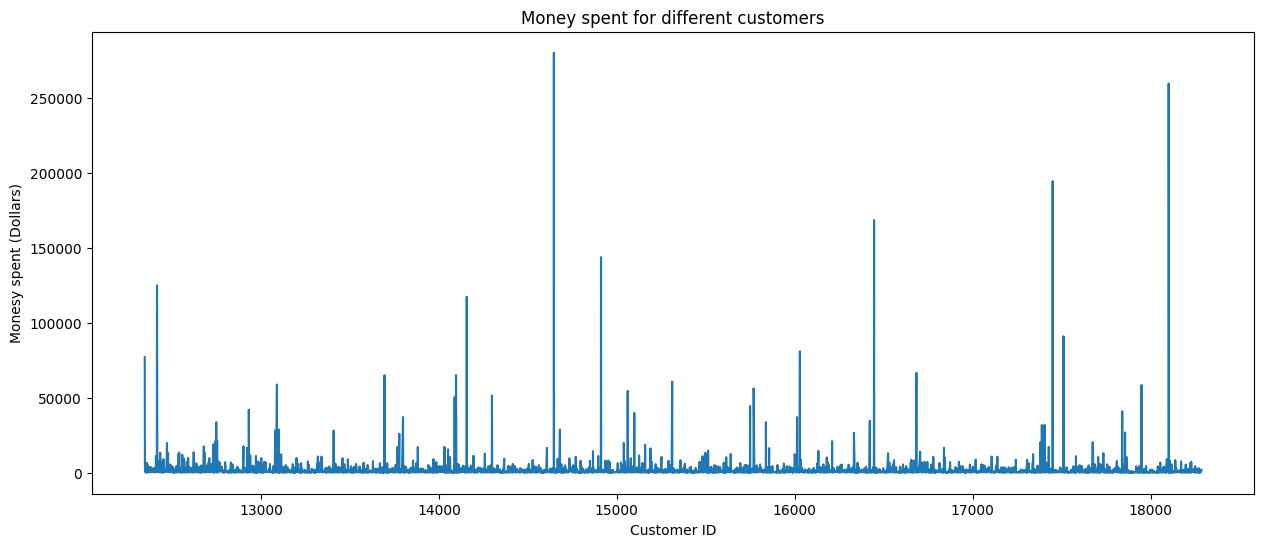

,invoice_num,invoice_date,year_month,month,day,hour,stock_code,description,quantity,unit_price,amount_spent,cust_id,country
0,536365,2010-12-01 08:26:00,201012,12,3,8,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,15.30,17850,United Kingdom
1,536365,2010-12-01 08:26:00,201012,12,3,8,71053,WHITE METAL LANTERN,6,3.39,20.34,17850,United Kingdom
2,536365,2010-12-01 08:26:00,201012,12,3,8,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,22.00,17850,United Kingdom
3,536365,2010-12-01 08:26:00,201012,12,3,8,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,20.34,17850,United Kingdom
4,536365,2010-12-01 08:26:00,201012,12,3,8,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,20.34,17850,United Kingdom


In [62]:
money_spent = df_new.groupby(by =  ['cust_id','country'],as_index = False)['amount_spent'].sum()
plt.subplots(figsize=(15,6))
plt.plot(money_spent.cust_id,money_spent.amount_spent)

plt.xlabel('Customer ID')
plt.ylabel('Monesy spent (Dollars)')
plt.title('Money spent for different customers')
plt.show()
df_new.head()

### How many orders (per day)?

In [63]:
df_new.groupby('invoice_num')['day'].unique()
df_new.groupby('invoice_num')['day'].unique().value_counts()
df_new.groupby('invoice_num')['day'].unique().value_counts().sort_index()

day
[1]    2863
[2]    3185
[3]    3455
[4]    4033
[5]    2831
[7]    2169
Name: count, dtype: int64

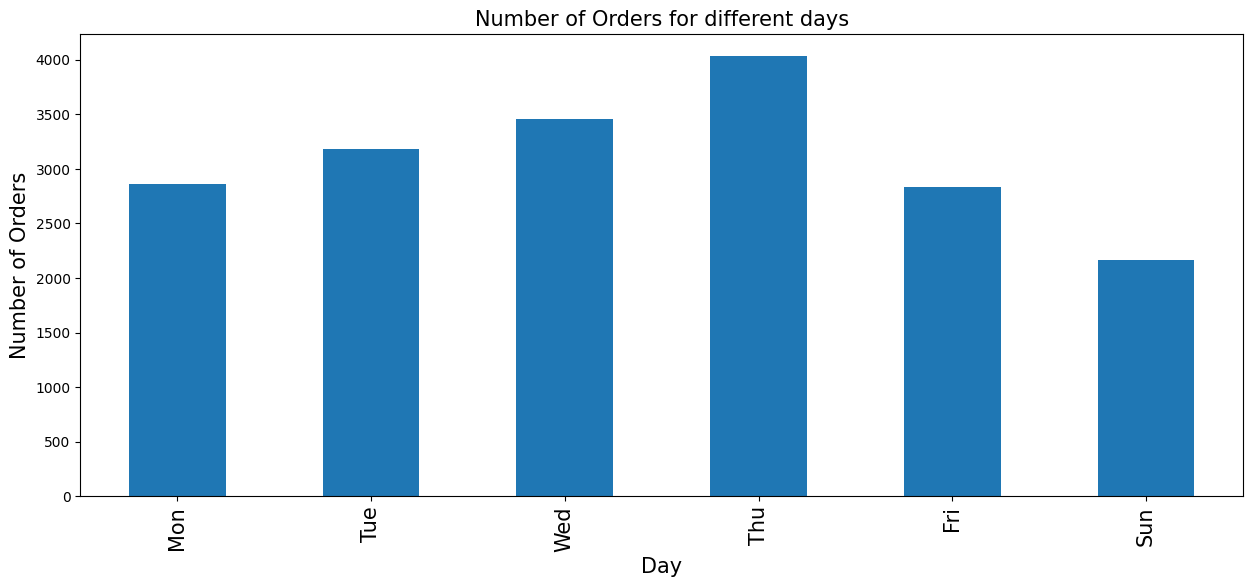

In [64]:
ax = df_new.groupby('invoice_num')['day'].unique().value_counts().sort_index().plot(kind = 'bar',figsize=(15,6))
ax.set_xlabel('Day',fontsize=15)
ax.set_ylabel('Number of Orders',fontsize=15)
ax.set_title("Number of Orders for different days",fontsize=15)
d = ('Mon','Tue','Wed','Thu','Fri','Sun')
ax.set_xticklabels(d,fontsize=15)
plt.show()

### How many orders for each country?

In [66]:
df['country'].value_counts()

country
United Kingdom          495478
Germany                   9495
France                    8557
EIRE                      8196
Spain                     2533
Netherlands               2371
Belgium                   2069
Switzerland               2002
Portugal                  1519
Australia                 1259
Norway                    1086
Italy                      803
Channel Islands            758
Finland                    695
Cyprus                     622
Sweden                     462
Unspecified                446
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
Israel                     297
USA                        291
Hong Kong                  288
Singapore                  229
Iceland                    182
Canada                     151
Greece                     146
Malta                      127
United Arab Emirates        68
European Community          61
RSA                         58


### Draw a horizontal bar graph for above

<Axes: ylabel='country'>

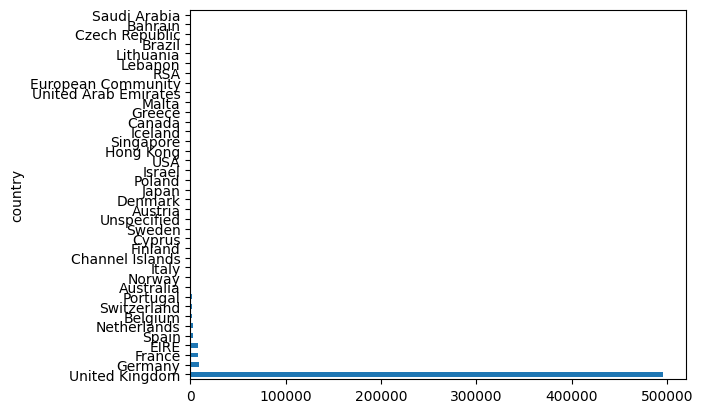

In [67]:
df['country'].value_counts().plot(kind='barh')

In [97]:
import os
print(os.path.abspath('data.csv'))

C:\Users\SKHAKH MUBASHSHIR\data.csv
